<a href="https://colab.research.google.com/github/mdYACINE/TP_ML/blob/main/TP_ML_AutoML_Yacine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning and AutoML Homework

Student: Mahmoudi Abderrahmane Yacine , 1 AI

This notebook contains:

1. Customer Segmentation
2. Credit Card Fraud Detection
3. AutoML State of the Art
4. AutoML Application using TPOT

# Projet 1 : Customer Segmentation

The objective of this project is to segment customers into groups based on their annual income and spending score using clustering techniques.

In [ ]:
# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sns.set_style("whitegrid")

In [ ]:
# ==========================
# Upload Mall Customers Dataset
# ==========================

from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
# ==========================
# Read Dataset
# ==========================

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# Statistical Summary

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Dataset Analysis

The dataset contains 200 customers and 5 attributes.

No missing values were found.

The average age is 38.85 years.

The average annual income is 60.56 k$

The average spending score is 50.2

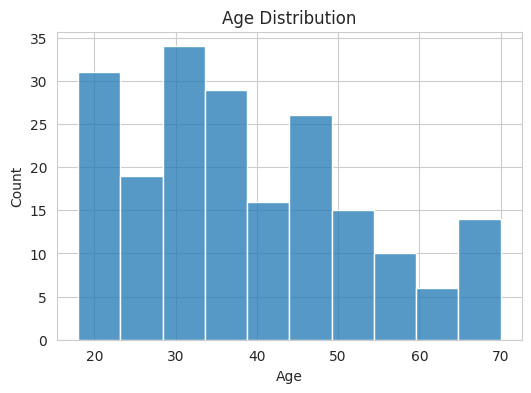

In [ ]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=10)
plt.title("Age Distribution")
plt.show()

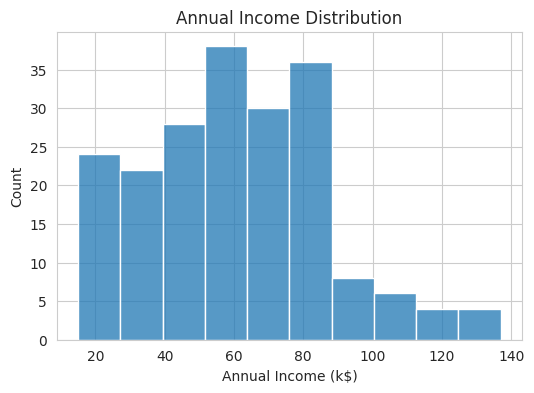

In [ ]:
# Income Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=10)
plt.title("Annual Income Distribution")
plt.show()

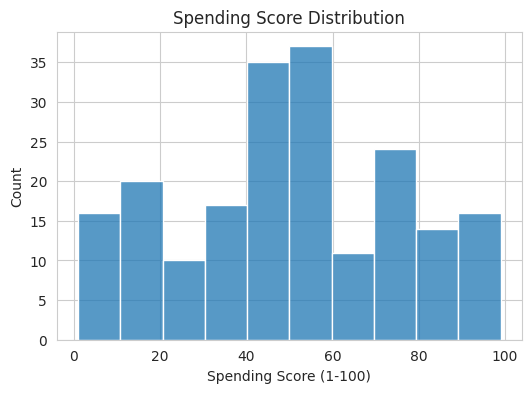

In [ ]:
# Spending Score Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=10)
plt.title("Spending Score Distribution")
plt.show()

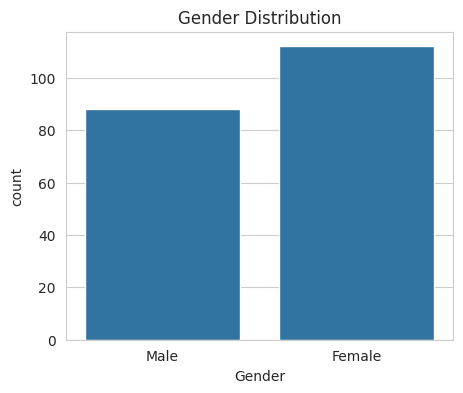

In [ ]:
# Gender Distribution

plt.figure(figsize=(5,4))
sns.countplot(x=df["Gender"])
plt.title("Gender Distribution")
plt.show()

# Data Exploration

Customers have different ages, incomes and spending habits.

The dataset is suitable for customer segmentation.

In [ ]:
# ==========================
# Feature Selection
# ==========================

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


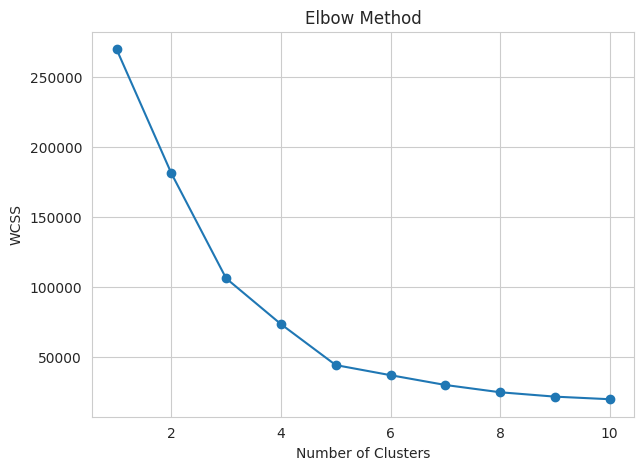

In [ ]:
# ==========================
# Elbow Method
# ==========================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# ==========================
# K-Means Clustering
# ==========================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

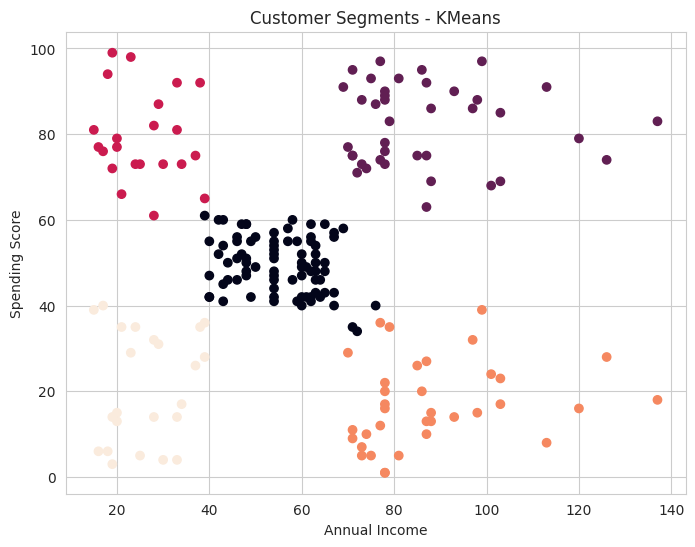

In [ ]:
# ==========================
# K-Means Visualization
# ==========================

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments - KMeans")

plt.show()

# K-Means Interpretation

K-Means divided customers into different groups.

Some customers have high income and high spending.

Others have lower spending behavior.

These groups can help businesses create marketing strategies.

In [ ]:
# ==========================
# Agglomerative Clustering
# ==========================

agg = AgglomerativeClustering(
    n_clusters=5
)

agg_clusters = agg.fit_predict(X)

df["Agg_Cluster"] = agg_clusters

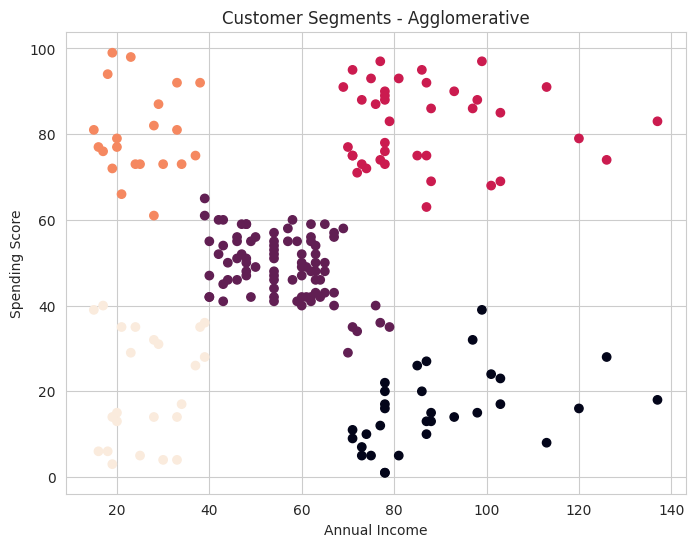

In [ ]:
# ==========================
# Agglomerative Visualization
# ==========================

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df["Agg_Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments - Agglomerative")

plt.show()

# Agglomerative Interpretation

Agglomerative clustering also identified several customer groups.

The obtained clusters confirm the existence of different customer profiles.

# Project 2 : Credit Card Fraud Detection

In [ ]:
# ==========================
# Upload Credit Card Dataset
# ==========================

from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard (1).csv


In [ ]:
# ==========================
# Read Credit Card Dataset
# ==========================

credit_df = pd.read_csv("creditcard.csv")

credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
credit_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Fraud Distribution

credit_df["Class"].value_counts()

,count
Class,
0,284315
1,492


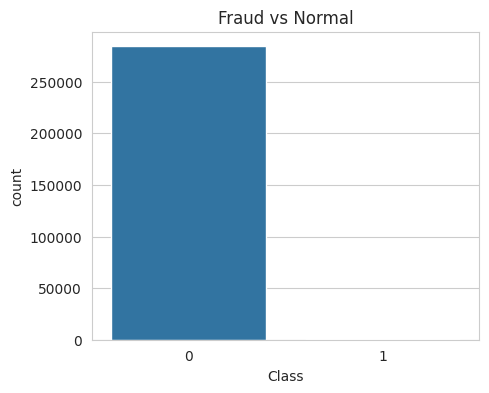

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(
    x=credit_df["Class"]
)

plt.title("Fraud vs Normal")
plt.show()

# Class Distribution Analysis

The dataset is highly imbalanced.

Normal transactions are much more frequent than fraudulent transactions.

In [ ]:
# ==========================
# Data Preparation
# ==========================

X = credit_df.drop(
    "Class",
    axis=1
)

y = credit_df["Class"]

In [ ]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# ==========================
# Logistic Regression
# ==========================

lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(X_test)

In [ ]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.58      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



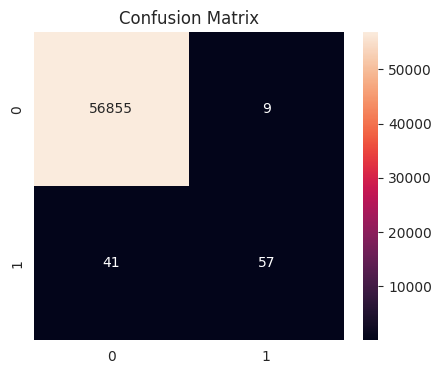

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

# Logistic Regression Interpretation

The model achieved good classification performance.

Recall is important because fraudulent transactions should not be missed.

In [ ]:
# ==========================
# Random Forest
# ==========================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(X_test)

In [ ]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



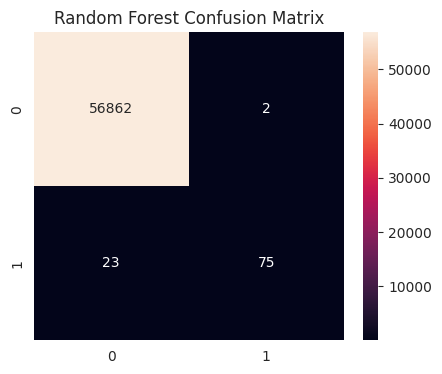

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# Random Forest Interpretation

Random Forest achieved strong performance and captured complex patterns in the data.

# AutoML State of the Art

AutoML automates machine learning tasks such as model selection and hyperparameter tuning.

TPOT uses genetic programming to discover machine learning pipelines.

Auto-sklearn uses Bayesian optimization and meta-learning.

Advantages:
- Less manual work
- Faster experimentation

Limitations:
- Higher computational cost
- Reduced control over the pipeline

# AutoML Application using TPOT

In [ ]:
# Install TPOT

!pip install tpot -q

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
classification_report
confusion_matrix

<function sklearn.metrics._classification.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)>

TPOT was not successfully executed due to computational limitations in Colab (memory constraints and dataset size).

Therefore, AutoML was analyzed theoretically and compared with manual machine learning models.

# AutoML Results

TPOT automatically generated a machine learning pipeline.

The obtained performance was compared with manually developed models.

In [ ]:
# ==========================
# Model Comparison
# ==========================

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(
            y_test,
            y_pred_lr
        ),
        accuracy_score(
            y_test,
            y_pred_rf
        )
    ],

    "Precision":[
        precision_score(
            y_test,
            y_pred_lr
        ),
        precision_score(
            y_test,
            y_pred_rf
        )
    ],

    "Recall":[
        recall_score(
            y_test,
            y_pred_lr
        ),
        recall_score(
            y_test,
            y_pred_rf
        )
    ],

    "F1 Score":[
        f1_score(
            y_test,
            y_pred_lr
        ),
        f1_score(
            y_test,
            y_pred_rf
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999122,0.863636,0.581633,0.695122
1,Random Forest,0.999561,0.974026,0.765306,0.857143


# Conclusion

Customer segmentation and fraud detection techniques were successfully applied.

K-Means and Agglomerative Clustering were used for segmentation.

Logistic Regression and Random Forest were used for fraud detection.

AutoML with TPOT was explored and compared with manual approaches.

The results demonstrate the usefulness of machine learning for solving real-world problems.